In [47]:
import numpy as np
import pandas as pd

In [48]:
df = pd.read_csv("/content/covid_toy.csv")

In [49]:
df.head(2)

,age,gender,fever,cough,city,has_covid
0,60,Male,103.0,Mild,Kolkata,No
1,27,Male,100.0,Mild,Delhi,Yes


In [50]:
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import DBSCAN

In [51]:
num_cols = ['age','fever']
cat_cols = ['gender','cough','city','has_covid']

In [52]:
num_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='mean')),
    ('scaler',StandardScaler())
])

cat_pipeline = Pipeline([
    ('encoder',OneHotEncoder(drop='first'))
])

preprocessor = ColumnTransformer([
    ('num',num_pipeline,num_cols),
    ('cat',cat_pipeline,cat_cols)
])

In [53]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'fever']),
                                ('cat',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(drop='first'))]),
                                 ['gender', 'cough', 'city', 'has_covid'])])

In [54]:
X = preprocessor.fit_transform(df)

In [55]:
# X

array([[ 0.63746697,  1.11190579,  1.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  0.        ],
       [-0.69563886, -0.43559196,  1.        ,  0.        ,  1.        ,
         0.        ,  0.        ,  1.        ],
       [-0.08968166,  0.08024062,  1.        ,  0.        ,  1.        ,
         0.        ,  0.        ,  0.        ],
       [-0.53405027, -1.46725713,  0.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  0.        ],
       [ 0.8394527 ,  0.08024062,  0.        ,  0.        ,  0.        ,
         0.        ,  1.        ,  0.        ],
       [ 1.60699847,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  1.        ],
       [-1.22080176,  0.08024062,  1.        ,  1.        ,  0.        ,
         0.        ,  0.        ,  0.        ],
       [-0.97841888,  0.        ,  0.        ,  1.        ,  0.        ,
         0.        ,  1.        ,  1.        ],
       [-1.01881603, -0.43559196

In [10]:
# Apply DBSCAN

In [56]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

clusters = dbscan.fit_predict(X)

df['Cluster'] = clusters

In [57]:
df.sample(3)

,age,gender,fever,cough,city,has_covid,Cluster
54,60,Female,99.0,Mild,Mumbai,Yes,0
20,12,Male,98.0,Strong,Bangalore,No,0
14,51,Male,104.0,Mild,Bangalore,No,0


In [58]:
df['Cluster'].value_counts()

,count
Cluster,
0,98
-1,2


In [14]:
# This means:

# Cluster 0 → 98 data points
# Noise (-1) → 2 data points

# No additional clusters were formed.

# What does this mean?

# According to DBSCAN, most of the records in the dataset are very similar
# to each other and therefore belong to the same cluster.

# In other words:

# "98 records are sufficiently close to each other and form a single dense region (Cluster 0)."

# The remaining 2 records are significantly different from the majority of the data.

# Therefore, DBSCAN considers them as noise points (outliers) and assigns them to cluster -1.

In [15]:
# Step 1: Examine the noise points

# This will display the two records that are considerably different from the
# majority of the dataset and have been classified as noise (outliers) by DBSCAN.

In [16]:
df[df['Cluster']==-1]

,age,gender,fever,cough,city,has_covid,Cluster
61,81,Female,98.0,Strong,Mumbai,No,-1
62,56,Female,104.0,Strong,Bangalore,Yes,-1


In [17]:
# Step 2: Summary of Cluster 0
# Average age and fever

In [18]:
df.groupby('Cluster')[['age','fever']].mean()

,age,fever
Cluster,,
-1,68.50000,101.000000
0,43.72449,100.840909


In [19]:
pd.crosstab(df['Cluster'],df['has_covid'])

has_covid,No,Yes
Cluster,,
-1,1,1
0,54,44


In [20]:
# Visualization

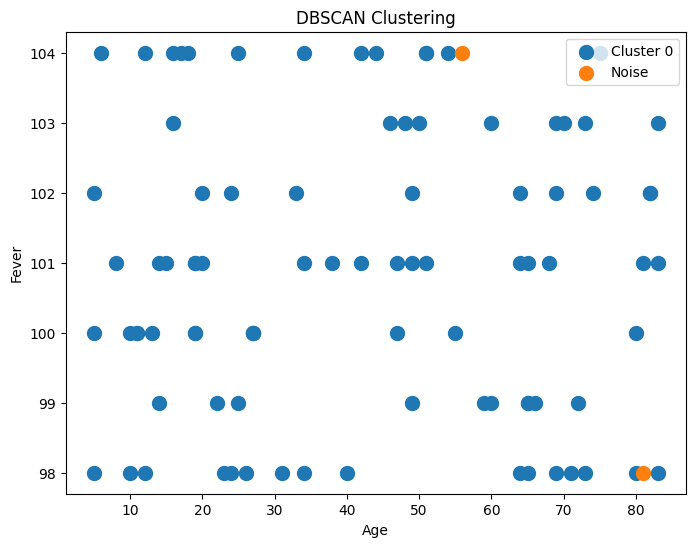

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for i in df['Cluster'].unique():

    if i == -1:
        label = "Noise"
    else:
        label = f"Cluster {i}"

    plt.scatter(
        df[df['Cluster']==i]['age'],
        df[df['Cluster']==i]['fever'],
        s=100,
        label=label
    )

plt.xlabel("Age")
plt.ylabel("Fever")
plt.title("DBSCAN Clustering")
plt.legend()
plt.show()

In [22]:
# Second DataSet

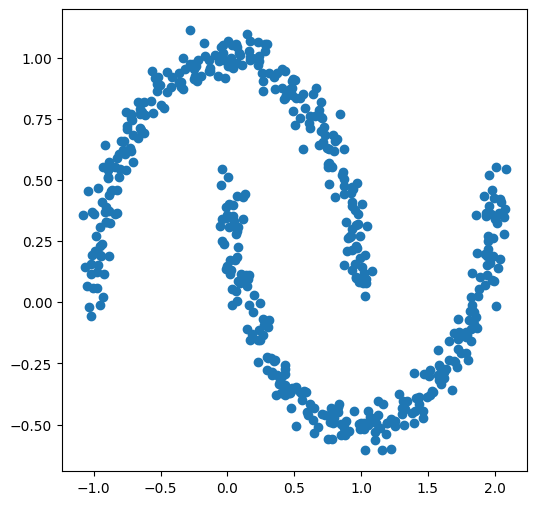

In [23]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

X, y = make_moons(
    n_samples=500,
    noise=0.05,
    random_state=42
)

plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1])
plt.show()

In [24]:
from sklearn.cluster import DBSCAN
import pandas as pd

dbscan = DBSCAN(
    eps=0.2,
    min_samples=5
)

clusters = dbscan.fit_predict(X)

pd.Series(clusters).value_counts()

,count
0,250
1,250


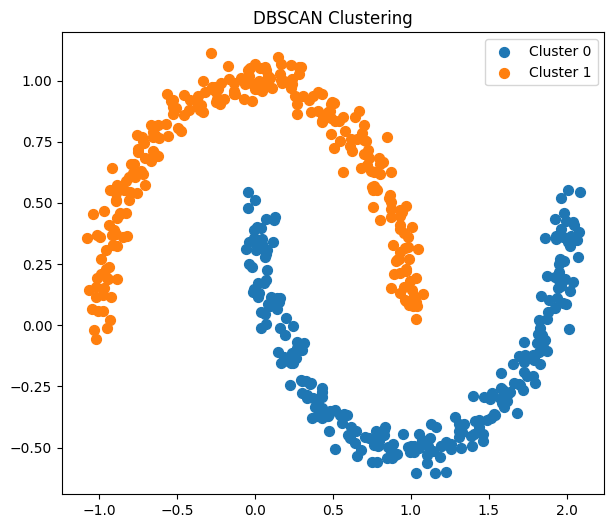

In [25]:
import numpy as np

plt.figure(figsize=(7,6))

for i in np.unique(clusters):

    if i == -1:
        label = "Noise"
    else:
        label = f"Cluster {i}"

    plt.scatter(
        X[clusters==i,0],
        X[clusters==i,1],
        s=50,
        label=label
    )

plt.title("DBSCAN Clustering")
plt.legend()
plt.show()

In [26]:
# The two most important hyperparameters in DBSCAN are:

# 1. eps (epsilon)
# 2. min_samples

# Once you understand these two parameters, you can fully understand how DBSCAN works.

# 1. What is Epsilon (eps)?

# eps represents a radius (distance).

# It determines:
# "What is the maximum distance within which two points are considered neighbors?"

# Suppose:

# A ●------● B ------● C
#      0.5       0.6

# If:

# eps = 1

# Then:

# A and B are neighbors.
# B and C are neighbors.
# Therefore, all three points can belong to the same cluster.

# However, if:

# eps = 0.3

# Then:

# None of the points will be considered neighbors.

# If eps is too small:

# eps = 0.1

# Result:

# Many points will be classified as noise (-1).
# Very small clusters will be formed.

# If eps is too large:

# eps = 3

# Result:

# Almost all points will be grouped into a single cluster.

# Example:

# Cluster 0 → 998 points
# Noise (-1) → 2 points

# This indicates that DBSCAN considers most of the data points to be similar
# and places them into one large cluster, while only a few points are treated as outliers.

In [27]:
# 2. What is min_samples?

# min_samples specifies the minimum number of neighboring points required
# for a point to be considered part of a cluster.

# Suppose:

# min_samples = 5

# This means that within the eps radius, a point must have at least
# 5 neighboring points.

# Only then will the point become part of a cluster.

# Example:

# Suppose:

# ● ● ● ● ● ●

# min_samples = 5

# Since there are enough neighboring points, a cluster will be formed.

# However, if:

# ● ● ●

# There are only 3 points.

# Since the minimum requirement of 5 points is not satisfied,

# these points will be classified as:

# -1 (Noise)

# In other words, they will be treated as outliers and will not belong
# to any cluster.

In [28]:
# How we select their values ?

In [29]:
# Method 1: Trial and Error

# We try different values of the hyperparameters and select the one
# that produces meaningful and well-separated clusters.

In [59]:
for eps in [0.2,0.3,0.5,0.7,1]:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = dbscan.fit_predict(X)

    print("eps =",eps)
    print(pd.Series(labels).value_counts())

eps = 0.2
-1    100
Name: count, dtype: int64
eps = 0.3
-1    100
Name: count, dtype: int64
eps = 0.5
-1    100
Name: count, dtype: int64
eps = 0.7
-1    100
Name: count, dtype: int64
eps = 1
-1    95
 0     5
Name: count, dtype: int64


In [31]:
# Method 2 (Rule of Thumb)
# min_samples
# Generally:

In [32]:
# min_samples = dimensions + 1

In [33]:
# Example:
# Agar dataset mein 4 features hain:
min_samples = 5

In [34]:
# or

In [35]:
# min_samples = 2 × dimensions

In [36]:
min_samples = 8

In [37]:
# Method 3: K-Distance Graph

# This is the most standard and professional method
# for selecting an appropriate value of epsilon (eps).

# Steps:

# Step 1:

In [38]:
from sklearn.neighbors import NearestNeighbors

In [39]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

In [40]:
distances = np.sort(distances[:,4])

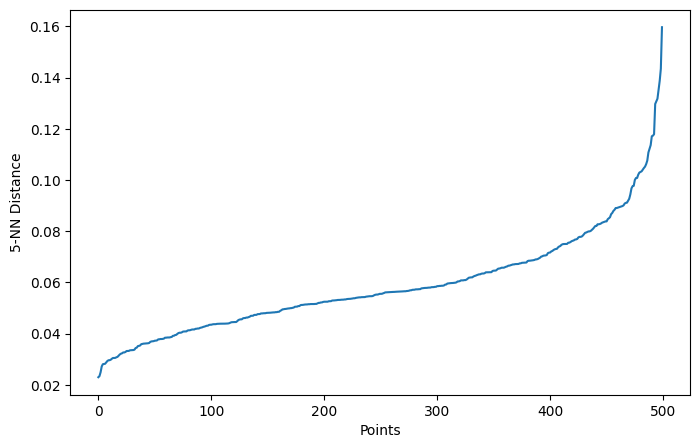

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(distances)
plt.xlabel("Points")
plt.ylabel("5-NN Distance")
plt.show()

In [42]:
# Now, an alternative approach to identify the point where the curve bends
# (i.e., the elbow point) is as follows:

In [43]:
!pip install kneed

In [60]:
from kneed import KneeLocator

# distances should already be sorted
kneedle = KneeLocator(
    x=range(len(distances)),
    y=distances,
    curve='convex',
    direction='increasing'
)

print("Best eps =", kneedle.knee_y)

Best eps = 0.09008661012524427


In [61]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.5,    ## because it is best fit
    min_samples=5
)

clusters = dbscan.fit_predict(X)